# Bank Customer Churn Prediction

## Objective
Predict customer churn using machine learning to support retention strategies.

## Models Used

- Logistic Regression
- Random Forest
- XGBoost

## Techniques Applied

- Feature Engineering
- SMOTE (Class imbalance)
- Hyperparameter Tuning
- ROC-AUC Evaluation
- Model Comparison

## Business Insights

Identified high-risk customer segments
based on tenure, activity level,
and product ownership.

## Deployment

FastAPI endpoint for real-time prediction.

## Import Libraries

In [2]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import model selection tools
from sklearn.model_selection import (
    train_test_split,  # For splitting data into training and testing sets
    GridSearchCV       # For hyperparameter tuning
)

# Import preprocessing tools
from sklearn.preprocessing import (
    LabelEncoder,   # For encoding categorical variables
    StandardScaler  # For standardizing features
)

# Import classification models
from sklearn.linear_model import LogisticRegression  # Linear classifier

from sklearn.ensemble import RandomForestClassifier  # Tree-based ensemble classifier

from xgboost import XGBClassifier  # Gradient boosting classifier

# Import evaluation metrics
from sklearn.metrics import (
    roc_auc_score,        # For calculating AUC score
    roc_curve,            # For plotting ROC curve
    classification_report # For detailed classification metrics
)

# Import class imbalance handling
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling Technique

# Import model persistence
import joblib  # For saving and loading models

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Load Dataset
- The dataset is loaded from a structured CSV file into a pandas DataFrame.

In [4]:
import os
os.getcwd()

'C:\\Users\\shrav\\Bank_Churn_Prediction'

In [7]:
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Data Cleaning
- This section removes non-informative or irrelevant columns such as unique identifiers and customer names.

- Columns removed:
  - RowNumber
  - CustomerId
  - Surname

In [16]:
# Drop non-informative columns

df.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1,
    inplace=True
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


## Feature Engineering

- Feature engineering transforms raw data into meaningful variables  that improve model performance. In this case it helps identify meaningful financial behavior patterns such as financial stability and customer loyalty indicators.

- Key transformations performed:

  - Encoding categorical variables (Gender, Geography)

  - Creating new derived features:
    - BalanceSalaryRatio
    - TenureAgeRatio

In [19]:
# Encode categorical variables
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# Create new engineered features
df["BalanceSalaryRatio"] = (
    df["Balance"] /
    (df["EstimatedSalary"] + 1)
)

df["TenureAgeRatio"] = (
    df["Tenure"] /
    (df["Age"] + 1)
)

In [21]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureAgeRatio
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False,0.000000,0.046512
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True,0.744670,0.023810
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False,1.401362,0.186047
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False,0.000000,0.025000
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True,1.587035,0.045455


## Train-Test Split

- The dataset is divided into training and testing subsets.

- Typical split:
  - Training set → 80%
  - Testing set → 20%

- Splitting the dataset ensures that models are evaluated on unseen data, which helps measure generalization performance and prevents overfitting.

In [24]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Handling Class Imbalance with SMOTE 

- Customer churn datasets typically contain fewer churned customers than retained customers, leading to class imbalance.

- Technique used:
   - SMOTE (Synthetic Minority Oversampling Technique)
   - What SMOTE does: Creates synthetic samples of minority-class observations to balance the dataset.
   - Why this matters: Without handling imbalance, models may become biased toward  predicting customer retention while failing to detect      churn risk.

- Business Impact: Improves detection of high-risk customers, enabling proactive retention strategies.

In [27]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: Exited
0    6370
1    1630
Name: count, dtype: int64
After SMOTE: Exited
1    6370
0    6370
Name: count, dtype: int64


## Feature Scaling (Logistic Regression)

- Feature scaling standardizes numerical variables so they have similar ranges.

- Technique used:
  - StandardScaler
  - Why this matters: Some algorithms, particularly Logistic Regression, rely on distance calculations and are sensitive to feature magnitude.

- Benefits:
  - Faster model convergence
  - Improved model accuracy
  - More stable optimization

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

## Model Training

### 1. Logistic Regression - Hyperparameter Tuning

- Logistic Regression is used as a baseline classification model.

- Technique applied:
  - GridSearchCV is used to optimize model parameters.
  - Hyperparameters tuned:
    - C (regularization strength)
    - Solver

- Why this matters: Hyperparameter tuning systematically tests parameter combinations to identify the best-performing model configuration.

- Business Impact: Improves prediction reliability, enabling better identification of customers likely to churn.

In [33]:
lr = LogisticRegression()

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(
    X_train_scaled,
    y_train_smote
)

best_lr = grid_lr.best_estimator_

print("Best LR Params:",
      grid_lr.best_params_)

Best LR Params: {'C': 1, 'solver': 'lbfgs'}


### 2. Random Forest - Hyperparameter Tuning
- Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive accuracy.

- Parameters tuned:
  - n_estimators
  - max_depth
  - min_samples_split

- Why this matters: Random Forest reduces overfitting and improves predictive stability compared to single decision trees.

- Business Impact: Captures complex customer behavior patterns that may indicate churn risk.

In [35]:
rf = RandomForestClassifier(
    random_state=42
)

param_grid_rf = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, None],

    "min_samples_split": [2, 5]

}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(
    X_train_smote,
    y_train_smote
)

best_rf = grid_rf.best_estimator_

print("Best RF Params:",
      grid_rf.best_params_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### 3. XGBoost - Hyperparameter Tuning
- XGBoost is a powerful gradient boosting algorithm widely used for structured data problems.

- Parameters tuned:
  - n_estimators
  - max_depth
  - learning_rate

- Why this matters: XGBoost often achieves superior predictive performance due to its ability to model complex nonlinear relationships.

- Business Impact: Produces highly accurate churn predictions, enabling early intervention and customer retention strategies.

In [37]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid_xgb = {

    "n_estimators": [200, 300],

    "max_depth": [4, 6],

    "learning_rate": [0.01, 0.05]

}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(
    X_train_smote,
    y_train_smote
)

best_xgb = grid_xgb.best_estimator_

print("Best XGB Params:",
      grid_xgb.best_params_)

Best XGB Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}


## Model Evaluation (ROC-AUC)
- Model performance is evaluated using the ROC-AUC metric.

- ROC-AUC measures: The model’s ability to distinguish between churned and retained customers.

- Why this matters:
  - Accuracy alone may be misleading in imbalanced datasets. 
  - ROC-AUC provides a more reliable performance measure.

- Business Impact: Improves confidence in identifying customers at risk of leaving.

In [39]:
models = {

    "Logistic Regression":
        (best_lr, X_test_scaled),

    "Random Forest":
        (best_rf, X_test),

    "XGBoost":
        (best_xgb, X_test)

}

results = {}

for name, (model, X_data) in models.items():

    y_prob = model.predict_proba(
        X_data
    )[:,1]

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results[name] = auc

    print(
        name,
        "ROC-AUC:",
        round(auc, 3)
    )

Logistic Regression ROC-AUC: 0.746
Random Forest ROC-AUC: 0.847
XGBoost ROC-AUC: 0.846


### Plot ROC Curve
- ROC curves visually compare model performance across multiple classification thresholds.

- What it shows:
  - True Positive Rate
  - False Positive Rate

- Why this matters: Visual comparison helps determine which model performs best across different sensitivity levels.

- Business Impact: Supports model selection decisions for production deployment.

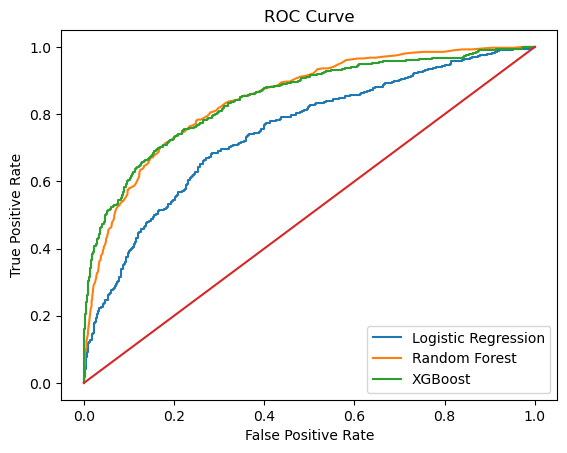

In [42]:
plt.figure()

for name, (model, X_data) in models.items():

    y_prob = model.predict_proba(
        X_data
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot([0,1],[0,1])

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

# Save image
plt.savefig("roc_curve.png", bbox_inches="tight") 

plt.show()

### Model Metrics

In [50]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(name)
    print(classification_report(y_test, y_pred))

    print(
        "ROC-AUC:",
        roc_auc_score(y_test, y_prob)
    )

    print("--------------")

Logistic Regression
              precision    recall  f1-score   support

           0       0.72      0.13      0.23      1593
           1       0.19      0.80      0.31       407

    accuracy                           0.27      2000
   macro avg       0.46      0.47      0.27      2000
weighted avg       0.62      0.27      0.24      2000

ROC-AUC: 0.46729086559595023
--------------
Random Forest
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1593
           1       0.57      0.63      0.59       407

    accuracy                           0.83      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.83      0.83      2000

ROC-AUC: 0.8465962110029908
--------------
XGBoost
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.58      0.64      0.61       407

    accuracy                           0.83      2000

### Confusion Matrix

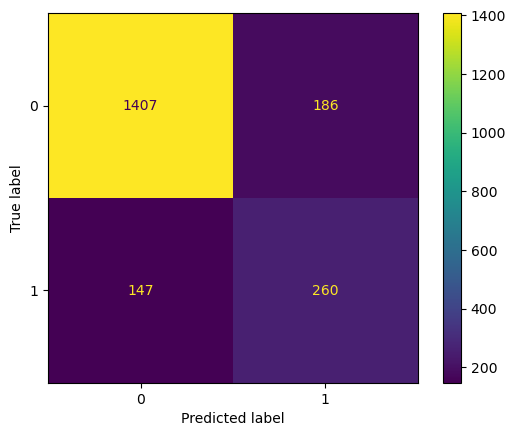

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_xgb.predict(X_test))

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.savefig("images/confusion_matrix.png")
plt.show()

## Feature Importance - Random Forest

- Feature importance identifies the variables that most strongly influence churn predictions.

- Method used: Random Forest feature importance ranking.

- Why this matters:Understanding influential features helps validate model behavior and align predictions with business expectations.

- Business Impact: Identifies actionable drivers of customer churn.

Age                   0.187206
IsActiveMember        0.102892
NumOfProducts         0.101354
TenureAgeRatio        0.090641
Balance               0.088586
EstimatedSalary       0.087020
CreditScore           0.078973
BalanceSalaryRatio    0.071637
Geography_Germany     0.059305
Gender                0.052658
dtype: float64


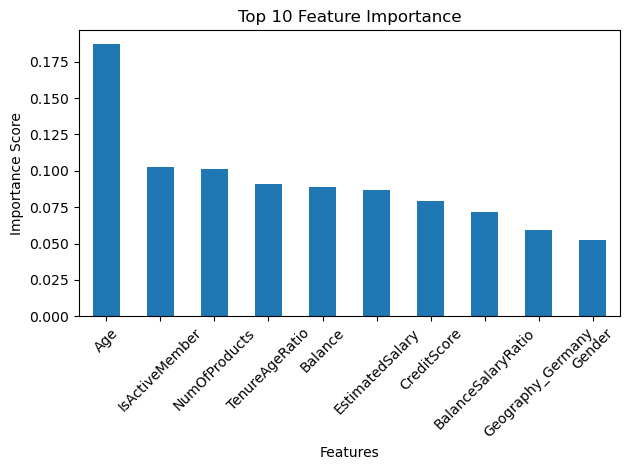

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

# Show Top Features
top_features = importance.head(10)

print(top_features)

# Plot Feature Importance

plt.figure()

top_features.plot(kind="bar")

plt.title(
    "Top 10 Feature Importance"
)

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/feature_importance_RF.png")

plt.show()

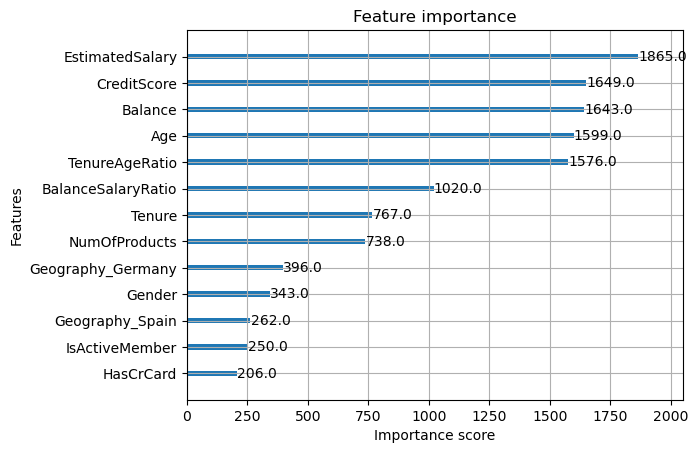

In [61]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(best_xgb)

plt.savefig("images/feature_importance_xgboost.png")

plt.show()

## Saving the Models

- Trained models are saved using joblib  for reuse without retraining.

- Why this matters: Saving models allows deployment into applications or APIs without repeating training processes.

- Business Impact: Supports real-time prediction workflows in production environments.

In [ ]:
import os
os.getcwd()

In [ ]:
#import os
import joblib

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    best_xgb,
    os.path.join(
        MODEL_DIR,
        "xgboost_model.pkl"
    )
)

joblib.dump(
    best_rf,
    os.path.join(
        MODEL_DIR,
        "random_forest.pkl"
    )
)

joblib.dump(
    best_lr,
    os.path.join(
        MODEL_DIR,
        "logistic_model.pkl"
    )
)

print("Models saved successfully.")

## Deployment (FastAPI)

In [ ]:
from fastapi import FastAPI
import joblib
import pandas as pd

# Initialize app
app = FastAPI()

# Load model
model = joblib.load(
    "C:/Users/shrav/Bank_Churn_Prediction/models/xgboost_model.pkl"
)

# Home route

@app.get("/")
def home():

    return {

        "message":
        "Bank Customer Churn Prediction API Running"

    }

# Preprocessing (must match notebook)

def preprocess_input(data):

    df = pd.DataFrame([data])

    # Encode Gender
    df["Gender"] = df["Gender"].map({
        "Female": 0,
        "Male": 1
    })

    # One-hot Geography
    df["Geography_Germany"] = (
        df["Geography"] == "Germany"
    ).astype(int)

    df["Geography_Spain"] = (
        df["Geography"] == "Spain"
    ).astype(int)

    df.drop(
        "Geography",
        axis=1,
        inplace=True
    )

    # Feature Engineering

    df["BalanceSalaryRatio"] = (
        df["Balance"] /
        (df["EstimatedSalary"] + 1)
    )

    df["TenureAgeRatio"] = (
        df["Tenure"] /
        (df["Age"] + 1)
    )

    return df


# Prediction endpoint

@app.post("/predict")

def predict(data: dict):

    processed = preprocess_input(data)

    prediction = model.predict(
        processed
    )[0]

    probability = model.predict_proba(
        processed
    )[0][1]

    return {

        "churn_prediction":
        int(prediction),

        "churn_probability":
        float(probability)

    }

## Deployment steps for Fast API - Swagger UI
- Save the fast api code as main.py file and open the Ananconda prompt. Then use the steps 
  - conda activate churn_env

  - cd Bank_Churn_Prediction

  - uvicorn app.main:app --reload

- Once Server Runs, open http://127.0.0.1:8000/docs to test the prediction

### Tried the API Test cases

- Test Case 1 — High Churn Risk
  - Typical risk pattern: Low tenure, Inactive,Single product

{
 "CreditScore": 580,
 "Geography": "Germany",
 "Gender": "Female",
 "Age": 45,
 "Tenure": 1,
 "Balance": 85000,
 "NumOfProducts": 1,
 "HasCrCard": 1,
 "IsActiveMember": 0,
 "EstimatedSalary": 40000
} 
  

- Test Case 2 — Low Churn Risk
  - Typical retention pattern: Active, Multiple products, Higher tenure

{
 "CreditScore": 720,
 "Geography": "France",
 "Gender": "Male",
 "Age": 35,
 "Tenure": 6,
 "Balance": 15000,
 "NumOfProducts": 2,
 "HasCrCard": 1,
 "IsActiveMember": 1,
 "EstimatedSalary": 85000
}

  

- Test Case 3 — Medium Risk
{
 "CreditScore": 640,
 "Geography": "Spain",
 "Gender": "Male",
 "Age": 50,
 "Tenure": 3,
 "Balance": 60000,
 "NumOfProducts": 2,
 "HasCrCard": 1,
 "IsActiveMember": 0,
 "EstimatedSalary": 60000
}

## Bulk Testing Method Using the test set

In [ ]:
import pandas as pd
import requests

df = pd.read_csv(
    "data/raw_test_customers.csv"
)

url = "http://127.0.0.1:8000/predict"

for i, row in df.iterrows():

    response = requests.post(
        url,
        json=row.to_dict()
    )

    print(response.json())

## Conclusion

- Key insights derived:
  - Customers with low tenure show higher churn risk
  - Inactive customers are more likely to churn
  - Customers with fewer products show higher churn probability